In [1]:
# ============================================================
# NOTEBOOK — PHASE 2 : EDA (Analyse Exploratoire)
# Tunis (2010–2024)
# ============================================================

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Options d'affichage ---
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# --- Chemin du fichier features (sortie de la Phase 1) ---
FEAT_PATH = "tunis_2010_2024_clean_features.csv"

# --- Logger simple ---
def log_ok(msg):   print(f"✅ {msg}")
def log_warn(msg): print(f"⚠️ {msg}")
def log_err(msg):  print(f"❌ {msg}")


In [2]:
# ============================================================
# Utils : lecture robuste + validations
# ============================================================

def assert_file_exists(path: str):
    # Vérifie que le fichier existe avant de l'ouvrir
    if not Path(path).exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")

def safe_read_csv(path: str, parse_dates=None):
    # Lecture robuste : utf-8-sig puis fallback latin-1 si besoin
    assert_file_exists(path)
    try:
        return pd.read_csv(path, parse_dates=parse_dates, encoding="utf-8-sig")
    except UnicodeDecodeError:
        log_warn("UnicodeDecodeError -> fallback encoding='latin-1'")
        return pd.read_csv(path, parse_dates=parse_dates, encoding="latin-1")

def require_columns(df: pd.DataFrame, cols: list, context: str):
    # Stop si colonnes manquantes
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{context} : colonnes manquantes -> {missing}")

In [3]:
# ============================================================
# 2.1 EDA — Tendances temporelles (journalières + mensuelles)
# ============================================================

def plot_series(df, col, title, ylabel):
    # Plot simple d'une série temporelle (jour par jour)
    if col not in df.columns:
        log_warn(f"{col} absent -> plot ignoré")
        return

    plt.figure()
    plt.plot(df["date"], df[col])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_monthly_mean(df, col, title, ylabel):
    # Plot des moyennes mensuelles (réduit le bruit des données quotidiennes)
    if col not in df.columns:
        log_warn(f"{col} absent -> plot mensuel ignoré")
        return

    monthly = df.set_index("date")[col].resample("M").mean()

    plt.figure()
    plt.plot(monthly.index, monthly.values)
    plt.title(title)
    plt.xlabel("Date (mensuel)")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [4]:
# ============================================================
# 2.2 EDA — Corrélations
# ============================================================

def correlation_heatmap(df):
    # Construit une matrice de corrélation sur les colonnes numériques
    num_df = df.select_dtypes(include=["number"]).copy()

    # Retirer quelques colonnes techniques si elles existent (pas toujours utiles)
    for c in ["YEAR", "MO", "DY", "DOY", "PS"]:
        if c in num_df.columns:
            num_df = num_df.drop(columns=[c])

    # Calcul de la corrélation
    corr = num_df.corr()

    # Heatmap simple via imshow
    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matrice de corrélation (variables numériques)")
    plt.tight_layout()
    plt.show()

    return corr


In [5]:
# ============================================================
# 2.3 EDA — Patterns : saisons, extrêmes, anomalies
# ============================================================

def climatologie_mensuelle(df, col="T2M_MAX"):
    # Moyenne par mois (cycle saisonnier)
    if col not in df.columns:
        log_warn(f"{col} absent -> climatologie ignorée")
        return None

    tmp = df.copy()
    tmp["mois"] = tmp["date"].dt.month
    clim = tmp.groupby("mois")[col].mean().reset_index()

    plt.figure()
    plt.plot(clim["mois"], clim[col])
    plt.title(f"Climatologie mensuelle — moyenne de {col}")
    plt.xlabel("Mois (1..12)")
    plt.ylabel(col)
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

    return clim

def top_extremes(df):
    # Identifie des événements extrêmes : plus chauds / plus pluvieux
    if "T2M_MAX" in df.columns:
        log_ok("Top 10 jours les plus chauds (T2M_MAX)")
        display(df.nlargest(10, "T2M_MAX")[["date", "T2M_MAX"]])

    if "PRECTOTCORR" in df.columns:
        log_ok("Top 10 jours les plus pluvieux (PRECTOTCORR)")
        display(df.nlargest(10, "PRECTOTCORR")[["date", "PRECTOTCORR"]])

def detect_anomalies_zscore(df, col="T2M_MAX", z_th=2.5):
    # Détecte des anomalies via z-score (valeurs très éloignées de la moyenne)
    if col not in df.columns:
        log_warn(f"{col} absent -> anomalies ignorées")
        return None

    # z = (x - mean) / std
    z = (df[col] - df[col].mean()) / df[col].std()

    tmp = df.copy()
    tmp[f"{col}_z"] = z

    # On garde les points où |z| dépasse le seuil
    anom = tmp[np.abs(tmp[f"{col}_z"]) >= z_th][["date", col, f"{col}_z"]].sort_values(f"{col}_z", ascending=False)

    log_ok(f"Anomalies détectées : |z| >= {z_th}")
    display(anom.head(30))

    return anom


In [6]:
# ============================================================
# 2.4 EDA — Comparaison entre années (comparative)
# ============================================================

def yearly_summary(df):
    # Résume des stats par année : moyenne/max T2M_MAX + somme pluie
    tmp = df.copy()
    tmp["annee"] = tmp["date"].dt.year

    agg = {}
    if "T2M_MAX" in tmp.columns:
        agg["T2M_MAX_mean"] = ("T2M_MAX", "mean")
        agg["T2M_MAX_max"]  = ("T2M_MAX", "max")
    if "PRECTOTCORR" in tmp.columns:
        agg["Rain_sum"] = ("PRECTOTCORR", "sum")

    if not agg:
        log_warn("Aucune colonne météo clé disponible pour yearly_summary")
        return None

    year_df = tmp.groupby("annee").agg(**agg).reset_index()

    # Plot simple : moyenne annuelle T2M_MAX
    if "T2M_MAX_mean" in year_df.columns:
        plt.figure()
        plt.plot(year_df["annee"], year_df["T2M_MAX_mean"])
        plt.title("Comparaison annuelle — moyenne T2M_MAX")
        plt.xlabel("Année")
        plt.ylabel("°C")
        plt.tight_layout()
        plt.show()

    # Plot simple : pluie annuelle
    if "Rain_sum" in year_df.columns:
        plt.figure()
        plt.plot(year_df["annee"], year_df["Rain_sum"])
        plt.title("Comparaison annuelle — cumul des précipitations")
        plt.xlabel("Année")
        plt.ylabel("mm/an")
        plt.tight_layout()
        plt.show()

    return year_df


✅ Dataset chargé : (5479, 21) | 2010-01-01 00:00:00 -> 2024-12-31 00:00:00


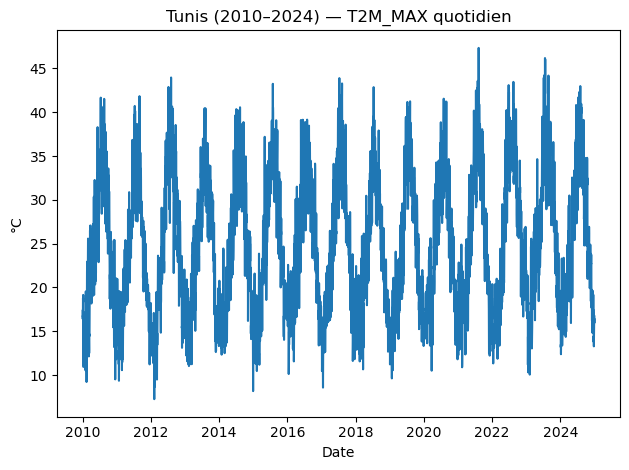

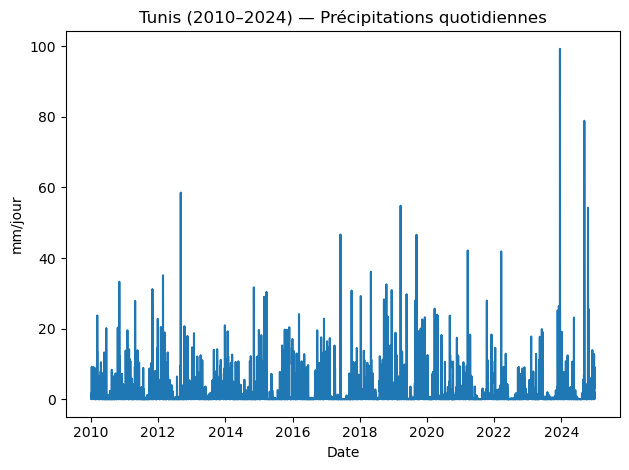

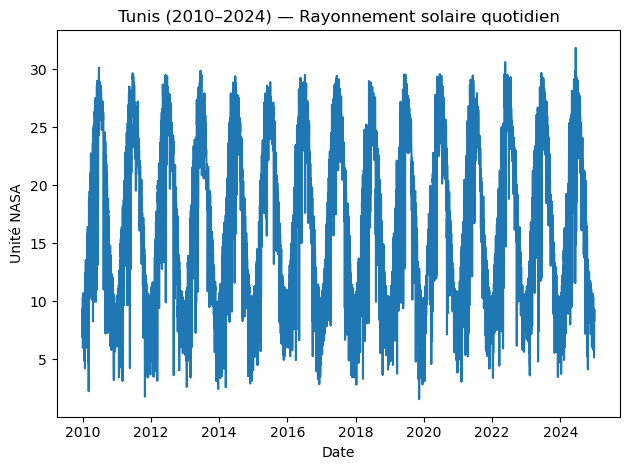

C:\Users\guerf\AppData\Local\Temp\ipykernel_6636\3153399043.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index("date")[col].resample("M").mean()


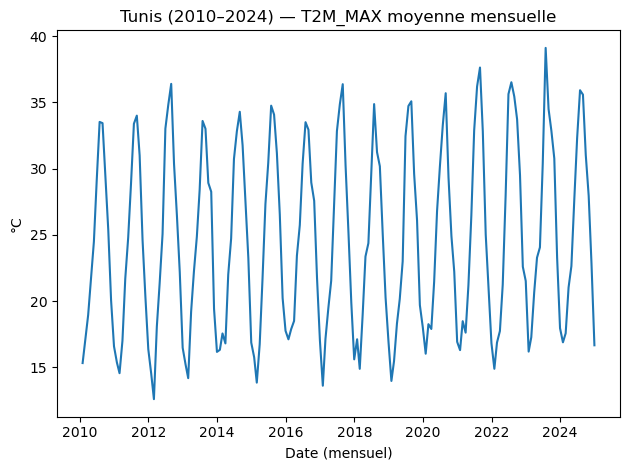

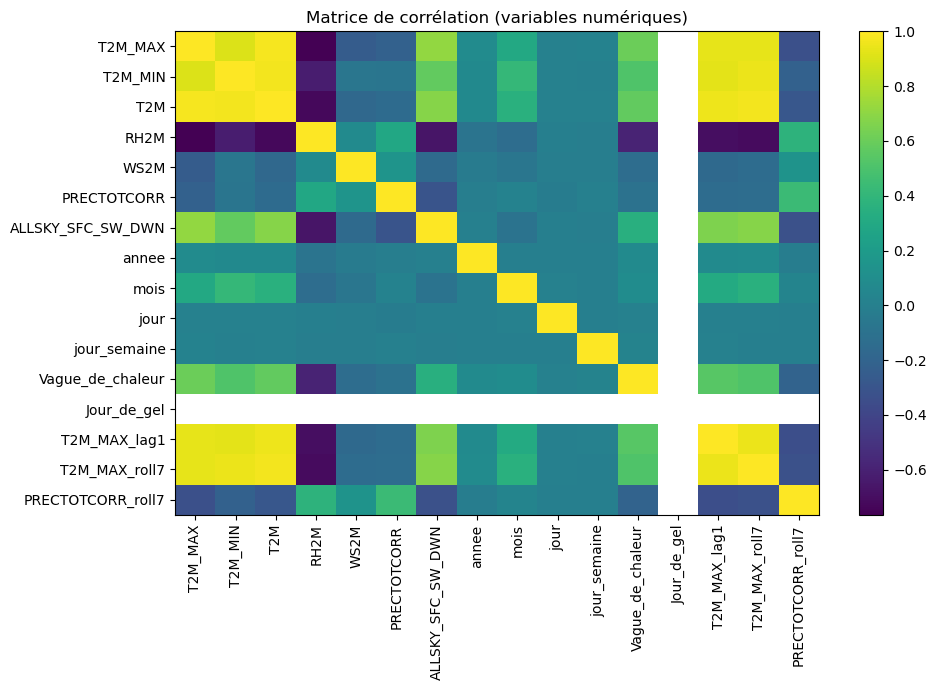

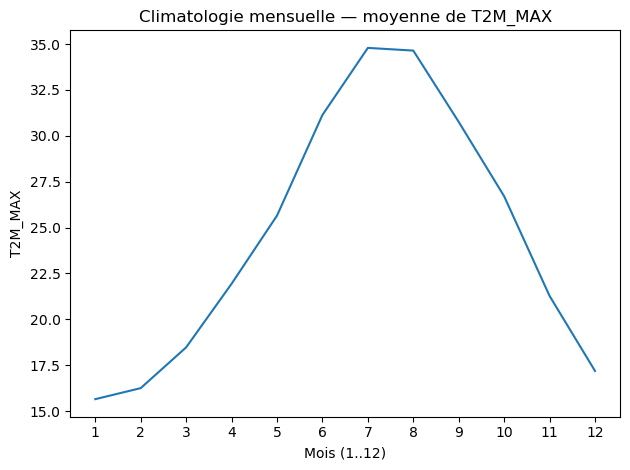

✅ Top 10 jours les plus chauds (T2M_MAX)


,date,T2M_MAX
4239,2021-08-10,47.35
4238,2021-08-09,46.34
4949,2023-07-21,46.19
4951,2023-07-23,46.07
4952,2023-07-24,45.98
4943,2023-07-15,44.25
4986,2023-08-27,44.19
947,2012-08-05,43.97
4936,2023-07-08,43.94
2748,2017-07-11,43.90


✅ Top 10 jours les plus pluvieux (PRECTOTCORR)


,date,PRECTOTCORR
5099,2023-12-18,99.26
5364,2024-09-08,78.88
975,2012-09-02,58.53
3366,2019-03-21,54.83
5404,2024-10-18,54.26
2712,2017-06-05,46.67
3539,2019-09-10,46.61
3365,2019-03-20,45.11
4096,2021-03-20,42.14
4460,2022-03-19,41.85


✅ Anomalies détectées : |z| >= 2.5


,date,T2M_MAX,T2M_MAX_z
4239,2021-08-10,47.35,2.990223
4238,2021-08-09,46.34,2.857583
4949,2023-07-21,46.19,2.837884
4951,2023-07-23,46.07,2.822125
4952,2023-07-24,45.98,2.810305
4943,2023-07-15,44.25,2.583110
4986,2023-08-27,44.19,2.575230
947,2012-08-05,43.97,2.546338
4936,2023-07-08,43.94,2.542398
2748,2017-07-11,43.90,2.537145


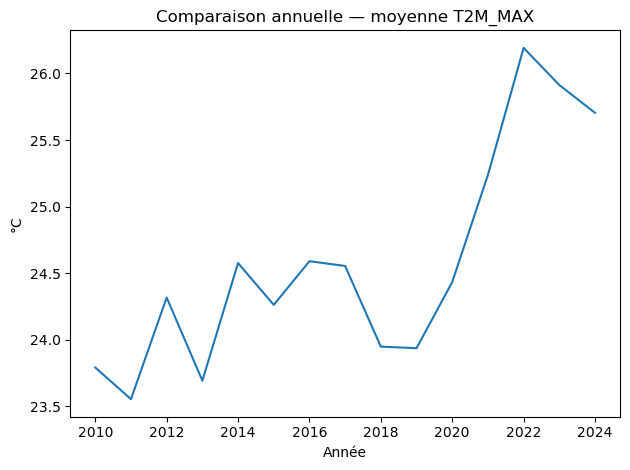

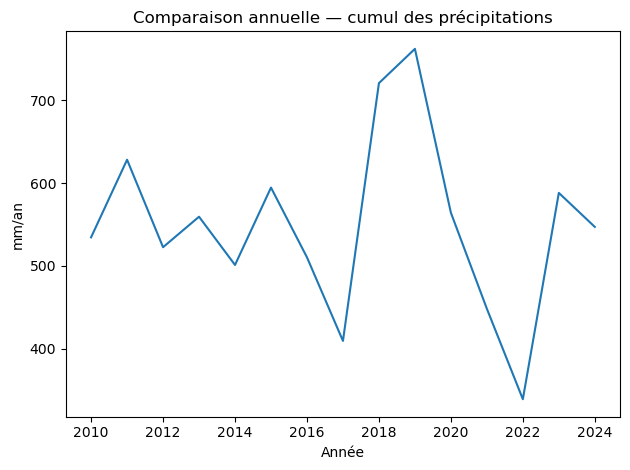

✅ Résumé annuel (aperçu)


,annee,T2M_MAX_mean,T2M_MAX_max,Rain_sum
0,2010,23.792411,41.67,534.40
1,2011,23.554986,41.84,628.13
2,2012,24.317650,43.97,522.49
3,2013,23.694027,40.45,559.29
4,2014,24.576219,40.57,501.05
5,2015,24.262548,43.25,594.48
6,2016,24.590328,39.16,510.29
7,2017,24.554493,43.90,409.32
8,2018,23.949096,42.87,720.62
9,2019,23.937616,41.25,762.02


✅ Phase 2 terminée ✅


,date,YEAR,DOY,T2M_MAX,T2M_MIN,T2M,RH2M,WS2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,annee,mois,jour,jour_semaine,saison,Type_de_jour,Vague_de_chaleur,Jour_de_gel,T2M_MAX_lag1,T2M_MAX_roll7,PRECTOTCORR_roll7
0,2010-01-01,2010,1,17.34,11.00,13.84,66.50,7.14,0.92,10.23,2010,1,1,4,Hiver,Nuageuse,0,0,17.34,17.340000,0.9200
1,2010-01-02,2010,2,16.42,11.59,13.74,72.61,5.96,1.64,6.84,2010,1,2,5,Hiver,Pluvieux,0,0,17.34,16.880000,1.2800
2,2010-01-03,2010,3,16.77,9.63,12.83,74.80,2.58,0.02,9.39,2010,1,3,6,Hiver,Nuageuse,0,0,16.42,16.843333,0.8600
3,2010-01-04,2010,4,16.71,7.91,11.65,71.33,2.14,0.01,5.96,2010,1,4,0,Hiver,Nuageuse,0,0,16.77,16.810000,0.6475
4,2010-01-05,2010,5,18.78,7.35,12.64,71.62,2.40,0.02,10.29,2010,1,5,1,Hiver,Nuageuse,0,0,16.71,17.204000,0.5220


In [7]:
# ============================================================
# RUN PHASE 2 — Exécution complète EDA
# ============================================================

def run_phase2():
    try:
        # 1) Charger le dataset features généré en Phase 1
        df = safe_read_csv(FEAT_PATH, parse_dates=["date"])
        df = df.sort_values("date").reset_index(drop=True)

        # 2) Vérifier la présence des colonnes indispensables
        require_columns(df, ["date"], "Phase 2")

        log_ok(f"Dataset chargé : {df.shape} | {df['date'].min()} -> {df['date'].max()}")

        # 3) Visualiser tendances temporelles (quotidiennes)
        plot_series(df, "T2M_MAX", "Tunis (2010–2024) — T2M_MAX quotidien", "°C")
        plot_series(df, "PRECTOTCORR", "Tunis (2010–2024) — Précipitations quotidiennes", "mm/jour")
        plot_series(df, "ALLSKY_SFC_SW_DWN", "Tunis (2010–2024) — Rayonnement solaire quotidien", "Unité NASA")

        # 4) Visualiser tendances mensuelles (plus lisible)
        plot_monthly_mean(df, "T2M_MAX", "Tunis (2010–2024) — T2M_MAX moyenne mensuelle", "°C")

        # 5) Corrélations
        corr = correlation_heatmap(df)

        # 6) Patterns / saisons (climatologie)
        climatologie_mensuelle(df, col="T2M_MAX")

        # 7) Extrêmes (chaud / pluvieux)
        top_extremes(df)

        # 8) Anomalies (z-score)
        detect_anomalies_zscore(df, col="T2M_MAX", z_th=2.5)

        # 9) Comparaison annuelle (moyennes, max, pluie)
        y = yearly_summary(df)
        if y is not None:
            log_ok("Résumé annuel (aperçu)")
            display(y.head(10))

        log_ok("Phase 2 terminée ✅")
        return df

    except Exception as e:
        log_err(f"Phase 2 échouée: {e}")
        raise

# --- Exécution ---
df_phase2 = run_phase2()

# --- Aperçu ---
df_phase2.head()